The following notebook contains a brief tutorial on data importation and preprocessing in python. In this tutorial we will use a publicly available Automatic Identification system (AIS) dataset from a danish strait. AIS is a standardized protocol that allows ships to broadcast their position and other information relevant to maritime safety and international regulations. Any AIS receiver in range can read these messages. In this first tutorial we will show how we can import the data stored in a csv file into a useable form in python. Next we will discuss strategies for handling incomplete or missing data, preparing data for machine learning techniques. Finally, we will also show how one can quickly visualize data using matplotlib.

In [1]:
import pandas as pd

What is pandas? Pandas is a python library that is used primarily for data analysis. It has many useful function including ones that allow for simple imports into python from common data formats such as json or csv. The heart of pandas is the pandas dataframe. Dataframes provide many capabilities to modify and extract information from the stored data.  

In [2]:
Complete_dataset=pd.read_csv('ais_data.csv')
print(Complete_dataset)

        Unnamed: 0       mmsi      navigationalstatus   sog    cog  heading  \
0                0  219019621           Unknown value   0.0   86.0     86.0   
1                1  265628170           Unknown value   0.0  334.5      NaN   
2                2  219005719           Unknown value   0.0  208.7      NaN   
3                3  219028066           Unknown value   0.0    NaN      NaN   
4                4  212584000                  Moored   0.0  153.0    106.0   
...            ...        ...                     ...   ...    ...      ...   
358346      387577  236125000  Under way using engine  11.0  171.9    169.0   
358347      387578  209717000  Under way using engine  16.6  341.6    343.0   
358348      387579  257182000  Under way using engine  20.6  340.7    341.0   
358349      387580  219007697           Unknown value  34.9   96.2      NaN   
358350      387581  261054050  Under way using engine  11.5  315.0    310.0   

           shiptype  width  length  draught  
0    

In this tabular dataset we have many data fields (i.e features). Some data fields are not always filled or have a placeholder value such as "unknown". The data fields are as follows:

mmsi:This is an id for a specific vessel 

navigational status: Vessels provide what maratime activities they are conducting, especially if they limit their maneuvrability (fishing)

sog:speed over ground in (knots)

cog:course over ground (degrees), where the boat is going

heading: Direction the ship is pointing

shiptype:Type of ship that is transmitting

width: Width of the ship (how wide it is)

length: Length of the ship

draught: How deep in the water the ship extends (important for navigation)

It goes without saying that the key to making good decisions regarding preprocessing is to understand the data you are trying to analyze thoroughly. This sometimes requires some investigation to determine exactly how to structure the data properly (is the data time-series, are certain features relevant? etc.). 



Missing data and incomplete data:

When we are creating our training dataset in a supervised learning context we frequently need to clean our dataset for missing and incomplete data. The action we take in this case is dependent on several factors. The first is how much data we have, how comfortable are we with the features we have (sometimes features can be very abstract and difficult to interpret) and do we expect our classifier when trained to have to handle data with incomplete data. 

Option 1:

The first safest option is to not use any data that has incomplete features in the training set, this can be a good option especially if the features are challenging to interpret so we can't easily determine a reasonable value to replace our missing feature.


Option 2:

The second option is to replace data with a standard value such as the mean value, the previous value or use a regression model to calculate the value. Option 2 requires careful 


First we will determine how many of our samples have missing data.

In [3]:
#Here calculate the number NaNs or incomplete values for each feature
rows_with_NaNs=Complete_dataset[
    Complete_dataset.isna().any(axis=1) |
    (Complete_dataset == "unknown value").any(axis=1)
]#isna() function determines if there are any NaN values in each row and we also check for unknown values as well

print(rows_with_NaNs)
Fraction_of_rows_with_NaN=len(rows_with_NaNs)/len(Complete_dataset)
print(Fraction_of_rows_with_NaN)

        Unnamed: 0       mmsi  navigationalstatus   sog    cog  heading  \
0                0  219019621       Unknown value   0.0   86.0     86.0   
1                1  265628170       Unknown value   0.0  334.5      NaN   
2                2  219005719       Unknown value   0.0  208.7      NaN   
3                3  219028066       Unknown value   0.0    NaN      NaN   
6                6  219006116       Unknown value   0.0    0.0      NaN   
...            ...        ...                 ...   ...    ...      ...   
358325      387556  219012671  Engaged in fishing   7.7  323.8    326.0   
358327      387558  219007697       Unknown value  44.7   96.4      NaN   
358332      387563  219007697       Unknown value  42.5   96.5      NaN   
358343      387574  219007697       Unknown value  37.4   96.1      NaN   
358349      387580  219007697       Unknown value  34.9   96.2      NaN   

           shiptype  width  length  draught  
0           Fishing    4.0     9.0      NaN  
1      

Next, using our knowledge of AIS we will try to replace a portion of the missing values. Firstly, as course over ground and heading are very similar (but technically distinct values) if either one of these values is valid and the other is missing we will replace for a given sample. Secondly, for the same mmsi number (the same ship) we will assume that ships maintain the same course and speed as previous values if they are missing. For static values such as length,width and draught any missing values will be replaced if any of the samples for the same mmsi number are present. In terms of missing navigational status information, we will simply treat this as a separate class in our categorical classification problem. Finally, we must handle the cases where a feature has invalid data for all samples of a given mmsi number (ship). A tempting option would be to use a mean value for a given class of ship to replace the missing value, however if our objective is to classify ships based upon their other features, then this could add bias to our experiment (our classifier could learn the significance of a certain inputted value rather than make classifications based upon the true available information. Hence, we will show we can replace these values with zeros to still allow us to use the data.

In [4]:
#First we will see if we can recover any static data using the mmsi number
#This takes a while given the large amount of data (1 hour+)
for _, current_row in Complete_dataset.iterrows():
    current_mmsi = current_row['mmsi']
    interim_dataframe = Complete_dataset.loc[
    Complete_dataset['mmsi'] == current_mmsi
].copy()

    #Next we conduct the following operations
    #Taking the interim dataframe, any cog, sog or heading info
    mask = interim_dataframe['cog'].isna() & interim_dataframe['heading'].notna()
    interim_dataframe.loc[mask, 'cog'] = interim_dataframe.loc[mask, 'heading']
    interim_dataframe['cog'] = interim_dataframe['cog'].ffill()
    #We assume if cog or heading information is missing we will assume they are the same
    interim_dataframe['sog'] = interim_dataframe['sog'].ffill()
    #sog information we will assume that it is the same as the last instance for the same mmsi
    mask = interim_dataframe['heading'].isna() & interim_dataframe['cog'].notna()
    interim_dataframe.loc[mask, 'heading'] = interim_dataframe.loc[mask, 'cog']
    interim_dataframe['heading'] = interim_dataframe['heading'].ffill()
    #Match with cog if possible
    interim_dataframe['width'] = interim_dataframe['width'].ffill()
    #Match with any previous value of the same mmsi
    interim_dataframe['length'] = interim_dataframe['length'].ffill()
    #match with any previous value of the same mmsi
    interim_dataframe['draught'] = interim_dataframe['draught'].ffill()
    #Next given all these changes we need to 
    Complete_dataset[
    Complete_dataset['mmsi'] == current_mmsi
]=interim_dataframe

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

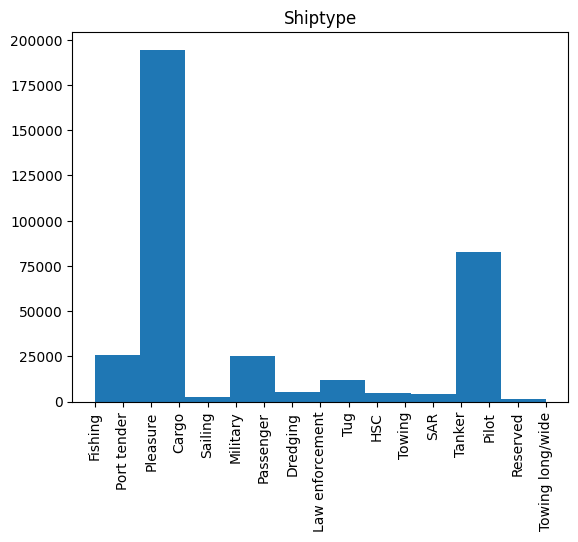

In [5]:
#Graphs
import matplotlib.pyplot as plt
shiptype=Complete_dataset['shiptype']
plt.hist(shiptype)
plt.title("Shiptype")
plt.xticks(rotation='vertical')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

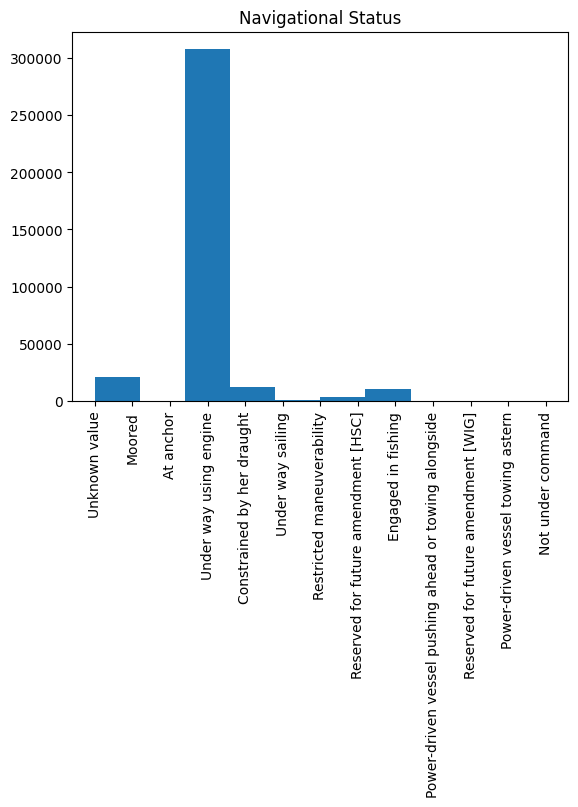

In [6]:
navstat=Complete_dataset['navigationalstatus']
plt.hist(navstat)
plt.title("Navigational Status")
plt.xticks(rotation='vertical')

Text(0.5, 1.0, 'Ship Width')

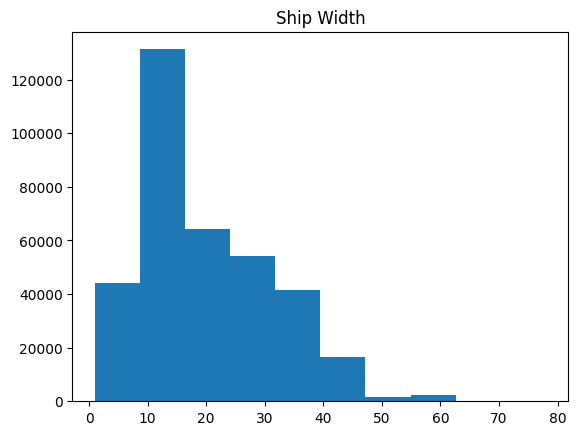

In [7]:
#width
width=Complete_dataset['width']
plt.hist(width)
plt.title("Ship Width")

Text(0.5, 1.0, 'Ship Length')

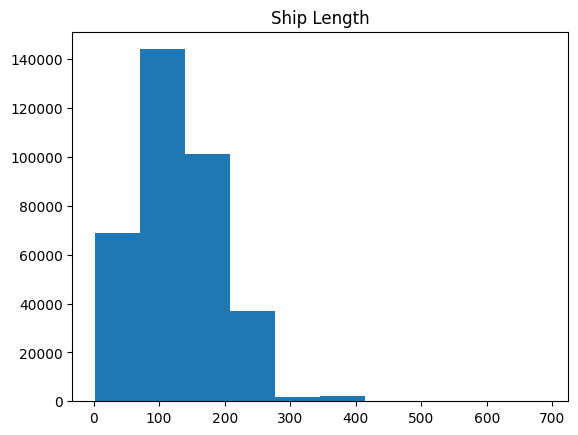

In [8]:
#length
length=Complete_dataset['length']
plt.hist(length)
plt.title("Ship Length")

Text(0.5, 1.0, 'Ship Draught')

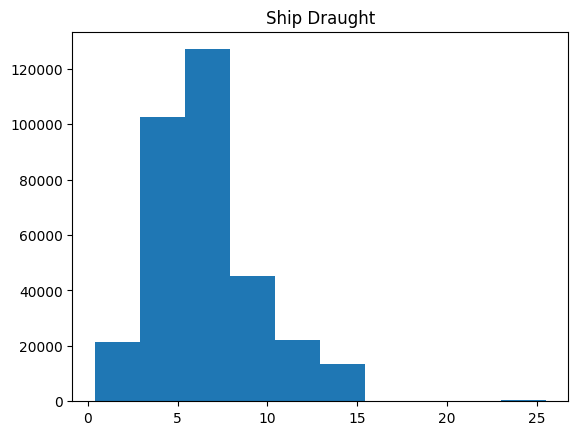

In [9]:
#draft
draft=Complete_dataset['draught']
plt.hist(draft)
plt.title("Ship Draught")

Next we will check how many NaNs are left after our changes

In [10]:
rows_with_NaNs=Complete_dataset[
    Complete_dataset.isna().any(axis=1) |
    (Complete_dataset == "unknown value").any(axis=1)
]

print(rows_with_NaNs)
Fraction_of_rows_with_NaN=len(rows_with_NaNs)/len(Complete_dataset)
print(Fraction_of_rows_with_NaN)

        Unnamed: 0       mmsi  navigationalstatus   sog    cog  heading  \
0                0  219019621       Unknown value   0.0   86.0     86.0   
1                1  265628170       Unknown value   0.0  334.5    334.5   
2                2  219005719       Unknown value   0.0  208.7    208.7   
3                3  219028066       Unknown value   0.0    NaN      NaN   
6                6  219006116       Unknown value   0.0    0.0      0.0   
...            ...        ...                 ...   ...    ...      ...   
358325      387556  219012671  Engaged in fishing   7.7  323.8    326.0   
358327      387558  219007697       Unknown value  44.7   96.4     96.4   
358332      387563  219007697       Unknown value  42.5   96.5     96.5   
358343      387574  219007697       Unknown value  37.4   96.1     96.1   
358349      387580  219007697       Unknown value  34.9   96.2     96.2   

           shiptype  width  length  draught  
0           Fishing    4.0     9.0      NaN  
1      

In [11]:
#Given that neural networks and other classifiers cannot handle NaN values we will replace the remaining NaN values with 0 to indicate to the classifier that the value is missing
#But still allow inference
#This is fairly simple in pandas
Complete_dataset = Complete_dataset.fillna(0)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

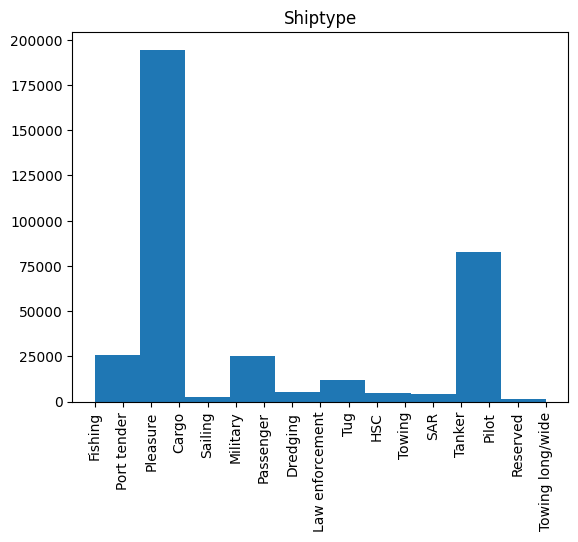

In [12]:
#Add graphs after NaN removal

shiptype=Complete_dataset['shiptype']
plt.hist(shiptype)
plt.title("Shiptype")
plt.xticks(rotation='vertical')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

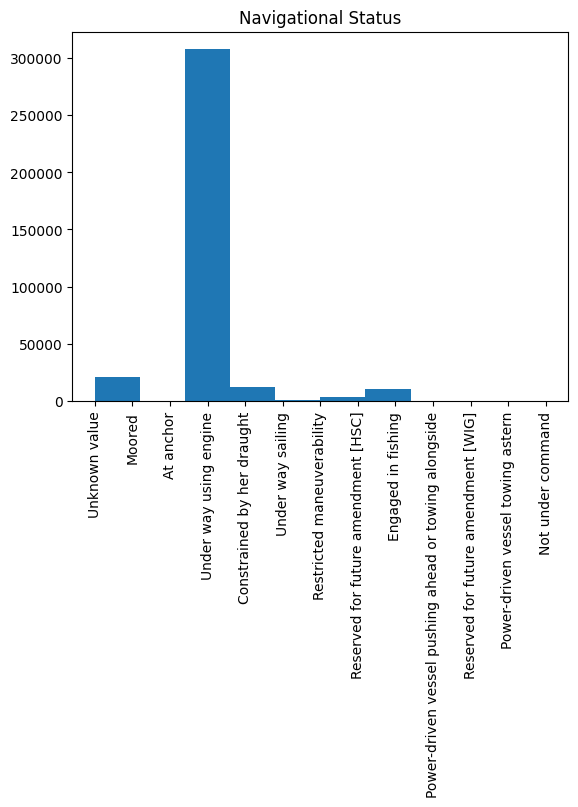

In [13]:
navstat=Complete_dataset['navigationalstatus']
plt.hist(navstat)
plt.title("Navigational Status")
plt.xticks(rotation='vertical')

Text(0.5, 1.0, 'Ship Width')

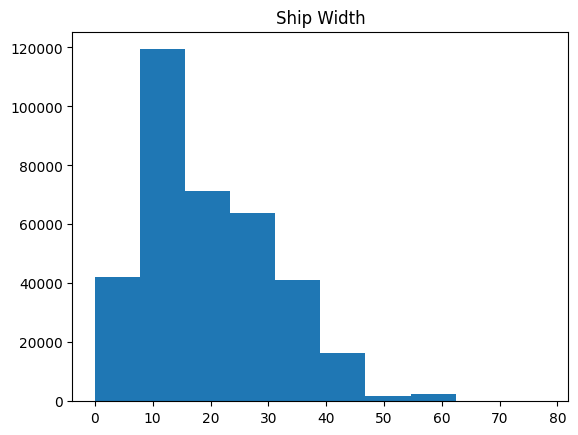

In [14]:
#width
width=Complete_dataset['width']
plt.hist(width)
plt.title("Ship Width")

Text(0.5, 1.0, 'Ship Length')

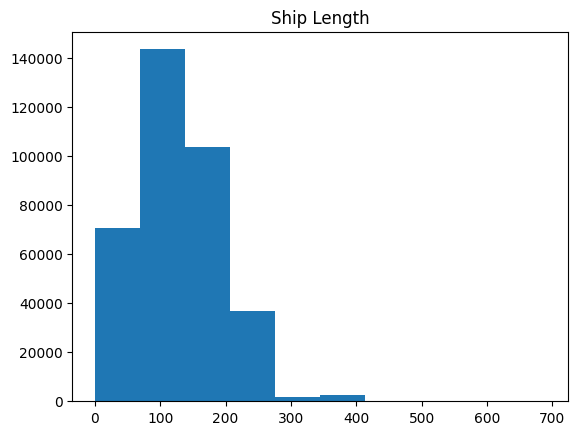

In [15]:
length=Complete_dataset['length']
plt.hist(length)
plt.title("Ship Length")

Text(0.5, 1.0, 'Ship Draught')

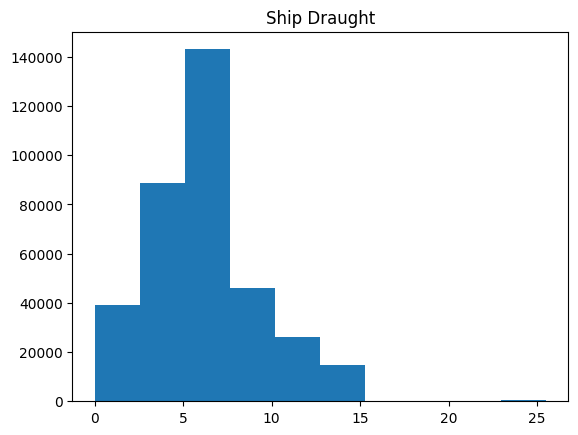

In [16]:
draft=Complete_dataset['draught']
plt.hist(draft)
plt.title("Ship Draught")

In the next seminar we will convert the data above into a format that can be fed into a neural network architecture. To accomplish this, encoding and normalization need to be conducted.




Next given that we have removed the undefined values from our dataset, we will normalize our input features. This step is important as neural networks and many other machine learning techniques perform best when values remain between 0 and 1. To start we will normalize the numeric features:

In [17]:
max_length=Complete_dataset["length"].max()
max_draught=Complete_dataset["draught"].max()
max_width=Complete_dataset["width"].max()
cog_max=360
heading_max=360
sog_max=Complete_dataset["sog"].max()
#Next we use these values to keep values between 0 and 1. This is important for many ML techniques as 
Complete_dataset["length"]=Complete_dataset["length"]/max_length
Complete_dataset["draught"]=Complete_dataset["draught"]/max_draught
Complete_dataset["width"]=Complete_dataset["width"]/max_width
Complete_dataset["cog"]=Complete_dataset["cog"]/cog_max
Complete_dataset["heading"]=Complete_dataset["heading"]/heading_max
Complete_dataset["sog"]=Complete_dataset["sog"]/sog_max

In terms of the navigational status we have two basic options. One-hot encoding or use an embedding layer. One-hot encoding involves basically creating a column for each potential class. For a particular sample if the value is of the specified class the column value is set to 1, otherwise it is zero. For a small number of potential classes this is a reasonable approach. The downsides of this approach is that it rapidly increases the dimensionality of the input features and becomes completely unfeasible when we try to deal with data such as user IDs or other identifiers. To handle this kind of data or features with a high number of categories, neural network embedding layers have become very popular. 

In [18]:
navigational_status_values={"Unknown value":0,"Moored":1,"Engaged in fishing":2, "Under way using engine":3,"Reserved for future amendment [WIG]":4,"Under way sailing":5,"Not under command":6,"Reserved for future amendment [HSC]":7,"At anchor":8}
Complete_dataset["navigationalstatus"] = pd.Categorical(
    Complete_dataset["navigationalstatus"],
    categories=navigational_status_values.keys()
)

one_hot = pd.get_dummies(Complete_dataset["navigationalstatus"], prefix="nav_status")
Complete_dataset = pd.concat([Complete_dataset, one_hot], axis=1)
print(Complete_dataset)

        Unnamed: 0       mmsi      navigationalstatus       sog       cog  \
0                0  219019621           Unknown value  0.000000  0.238889   
1                1  265628170           Unknown value  0.000000  0.929167   
2                2  219005719           Unknown value  0.000000  0.579722   
3                3  219028066           Unknown value  0.000000  0.000000   
4                4  212584000                  Moored  0.000000  0.425000   
...            ...        ...                     ...       ...       ...   
358346      387577  236125000  Under way using engine  0.051402  0.477500   
358347      387578  209717000  Under way using engine  0.077570  0.948889   
358348      387579  257182000  Under way using engine  0.096262  0.946389   
358349      387580  219007697           Unknown value  0.163084  0.267222   
358350      387581  261054050  Under way using engine  0.053738  0.875000   

         heading     shiptype     width    length   draught  \
0       0.23

The last feature that we need to handle is mmsi number. As there are thousands of mmsi numbers in our dataset we cannot easily use simple strategies such as One-Hot encoding. Hence, we will use a neural network embedding layer to convert the mmsi feature numbers into a format that can be easily handled by subsequent neural network layers or other machine learning techniques. Basically we are going to convert our mmsi numbers into a vector of values of a certain size. Embedding layers have trainable parameters that can be adjusted by backpropagation and can very efficiently represent relatively large feature spaces. The embedding outputs a continuous value from the discrete inputs (categorical works too). The first step we will take is to determine how many mmsi numbers are present in our dataset, this will inform the input dimension of our embedding:

In [19]:
import torch.nn as nn
Complete_dataset["mmsi"] = Complete_dataset["mmsi"].astype("category").cat.codes
num_vessels = Complete_dataset["mmsi"].nunique()
print(num_vessels)

3894


Now that we know the number of different mmsi numbers we need to represent (if we were to deploy this system in real life we might need to make different assumptions regarding how many mmsi numbers we need to be able to represent), we need to define a basic model with our embedding that takes the mmsi number and other relevant features and predicts the ship type at its output

In [27]:
#Initial Machine learning model definition
class Model(nn.Module):
    def __init__(self, num_vessels, embedding_dim, num_numeric_features):
        super().__init__()

        self.mmsi_embed = nn.Embedding(
            num_embeddings=num_vessels,
            embedding_dim=embedding_dim
        )

        self.input_dim = embedding_dim + num_numeric_features 
        
        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 17)
        
    def forward(self, mmsi, numeric_features):
        mmsi_emb = self.mmsi_embed(mmsi)
        #print("mmsi_emb.shape:", mmsi_emb.shape)
        #print("numeric_features.shape:", numeric_features.shape)
        x = torch.cat([mmsi_emb, numeric_features], dim=1)
        #print("x.shape after concat:", x.shape)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x) 
        return x

In [28]:
import torch.nn as nn
Complete_dataset["mmsi"] = Complete_dataset["mmsi"].astype("category").cat.codes
num_vessels = Complete_dataset["mmsi"].nunique()
print(num_vessels)

embedding_dim = 16

embedding = nn.Embedding(num_vessels, embedding_dim)
#Cleaned up Dataset
mmsi_column=Complete_dataset['mmsi']
sog_column=Complete_dataset['sog']
cog_column=Complete_dataset['cog']
heading_column=Complete_dataset['heading']
length_column=Complete_dataset['length']
width_column=Complete_dataset['width']
draught_column=Complete_dataset['draught']
#Next the navigational status one hot encoding
feature_dataset=pd.concat([sog_column,cog_column,heading_column,length_column,width_column,draught_column,one_hot],axis=1)
print(feature_dataset)

3894
             sog       cog   heading    length     width   draught  \
0       0.000000  0.238889  0.238889  0.013043  0.051282  0.000000   
1       0.000000  0.929167  0.929167  0.039130  0.102564  0.000000   
2       0.000000  0.579722  0.579722  0.015942  0.051282  0.000000   
3       0.000000  0.000000  0.000000  0.017391  0.038462  0.000000   
4       0.000000  0.425000  0.294444  0.143478  0.166667  0.247059   
...          ...       ...       ...       ...       ...       ...   
358346  0.051402  0.477500  0.469444  0.118841  0.153846  0.164706   
358347  0.077570  0.948889  0.952778  0.246377  0.346154  0.349020   
358348  0.096262  0.946389  0.947222  0.324638  0.461538  0.270588   
358349  0.163084  0.267222  0.267222  0.010145  0.038462  0.000000   
358350  0.053738  0.875000  0.861111  0.046377  0.102564  0.235294   

        nav_status_Unknown value  nav_status_Moored  \
0                              1                  0   
1                              1            

In [29]:
#Training, Validation and test set definition
#We use sklearn to divide the datasets into training, validation and testing



shipType=Complete_dataset['shiptype']
print(shipType)
import sklearn as sk
import torch
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

mmsi_data=Complete_dataset['mmsi']
mmsi_encoder = LabelEncoder()
mmsi_encoded = mmsi_encoder.fit_transform(Complete_dataset['mmsi'])
X_mmsi_train, X_mmsi_test, \
X_num_train, X_num_test, \
y_train, y_test = sk.model_selection.train_test_split(
    mmsi_encoded,
    feature_dataset,
    shipType,
    test_size=0.1,
    shuffle=False
)

X_mmsi_train, X_mmsi_val, \
X_num_train, X_num_val, \
y_train, y_val = sk.model_selection.train_test_split(
    X_mmsi_train,
    X_num_train,
    y_train,
    test_size=0.1,
    shuffle=False
)
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
#Next we need to feed these into the basic pytorch model

X_mmsi_train_t = torch.tensor(X_mmsi_train, dtype=torch.long)
X_mmsi_val_t   = torch.tensor(X_mmsi_val, dtype=torch.long)

X_num_train_t = torch.tensor(X_num_train.to_numpy(), dtype=torch.float32)
X_num_val_t   = torch.tensor(X_num_val.to_numpy(), dtype=torch.float32)

y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_val_t   = torch.tensor(y_val_enc, dtype=torch.long)
train_dataset = TensorDataset(
    X_mmsi_train_t,
    X_num_train_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_mmsi_val_t,
    X_num_val_t,
    y_val_t
)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)




0             Fishing
1         Port tender
2             Fishing
3            Pleasure
4               Cargo
             ...     
358346          Cargo
358347          Cargo
358348      Passenger
358349          Pilot
358350        Fishing
Name: shiptype, Length: 358351, dtype: object
